In [1]:
import matplotlib.patches as patches
import sys
sys.path.append("../src/")
from constrained_likelihood_surrogates import *

default_col_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

line_style_list = ['-', '--', '-.', ':', '-', (0, (3, 5, 1, 5, 1, 5))]
col_list = ['tab:blue', 'tab:orange', 'tab:green', 'tab:pink', 'tab:purple', 'tab:brown', 'tab:red', 'tab:gray', 'tab:olive', 'tab:cyan']

load_folder_name = './results/est-stat/'

In [2]:
# # Load results

test_type = 'statistics'
#stat_name_list = ['mean_val', 'second_mom', 'third_mom', 'fourth_mom', 'max_val', 'variance', 'coef_var', 'dispersion', 'skew', 'kurtosis', 'evi_mom', 'evi_smooth']

# N_list = [2**n for n in range(2, 11)]
# N_tick_list = N_list[0::4]
N_list = [2**n for n in range(2, 9)]
N_tick_list = N_list[0::2]
num_N = len(N_list)

lower_cutoff = 1
num_surr = 10
num_tests = 10000
process_list = ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']
num_processes = len(process_list)
method_list = ['const.', 'typic.', 'orig.', 'true', 'bootstrap'];
num_methods = len(method_list)
num_stats = 12

mean_stat_mat = np.zeros((num_N, num_methods, num_processes, num_tests, num_stats))
var_stat_mat = np.zeros((num_N, num_methods, num_processes, num_tests, num_stats))

for i_N in range(num_N):
    N = N_list[i_N]
    num_trans = N*(int(np.ceil(np.log2(N*1024))))
    save_str_0 = test_type + '_xmin-' + str(lower_cutoff) + '_N-' + str(N) + '_ntra-' + str(num_trans) + '_nsur-' + str(num_surr) + '_ntes-' + str(num_tests) + '_ntyp-' + str(num_methods) + '_npro-' + str(num_processes) + '_nstats-' + str(num_stats)
    process_str = '_p-1.5_l--1-1_e-1_t--1-1_u-9'
    save_str = save_str_0 + process_str
    with open(load_folder_name + save_str + '.json', 'r') as read_file:
        save_dict = json.load(read_file)

    mean_stat_list_list_list = np.array(save_dict['mean_stat_list_list_list'])#num_methods x num_processes x num_tests x num_stats
    var_stat_list_list_list = np.array(save_dict['var_stat_list_list_list'])#num_methods x num_processes x num_tests x num_stats
    #N = save_dict['N']
    #num_trans = save_dict['num_trans']
    #process_str = save_dict['process_str']
    #save_str = save_dict['save_str']
    #process_time_list = save_dict['process_time_list']
    mean_stat_mat[i_N, :, :, :, :] = mean_stat_list_list_list#num_N x num_methods x num_processes x num_tests x num_stats
    var_stat_mat[i_N, :, :, :, :] = var_stat_list_list_list#num_N x num_methods x num_processes x num_tests x num_stats

mean_mean_mat = np.mean(mean_stat_mat, axis=3)#num_N x num_methods x num_processes x num_stats
mean_var_mat = np.mean(var_stat_mat, axis=3)#num_N x num_methods x num_processes x num_stats
var_mean_mat = np.var(mean_stat_mat, axis=3)#num_N x num_methods x num_processes x num_stats
var_var_mat = np.var(var_stat_mat, axis=3)#num_N x num_methods x num_processes x num_stats

true_mean_stat_mat = mean_stat_mat[:, 3, :, :, :]
true_mean_stat_mat = np.expand_dims(true_mean_stat_mat, 1)
err_mean_stat_mat = mean_stat_mat - true_mean_stat_mat#num_N x num_methods x num_processes x num_tests x num_stats
err2_mean_stat_mat = err_mean_stat_mat**2#num_N x num_methods x num_processes x num_tests x num_stats
rmse_mean_mat = np.sqrt(np.mean(err2_mean_stat_mat, axis=3))#num_N x num_methods x num_processes x num_stats

test_type = save_dict['test_type']
lower_cutoff = save_dict['lower_cutoff']
num_surr = save_dict['num_surr']
num_tests = save_dict['num_tests']
num_methods = save_dict['num_methods']
process_list = save_dict['process_list']
process_dict = save_dict['process_dict']
stat_name_list = save_dict['stat_name_list']
method_list = save_dict['method_list']

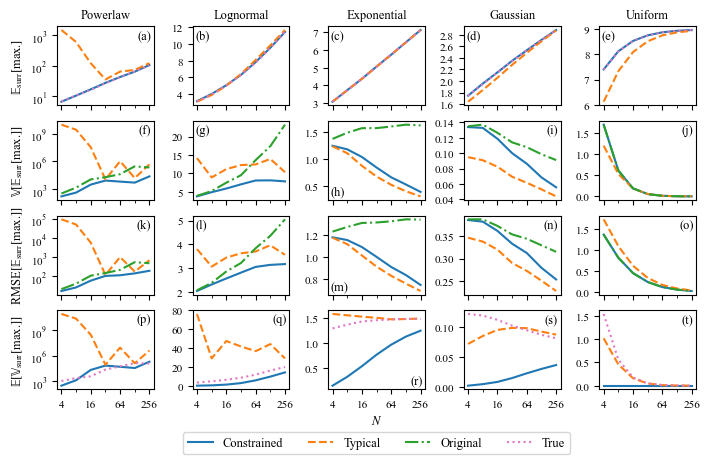

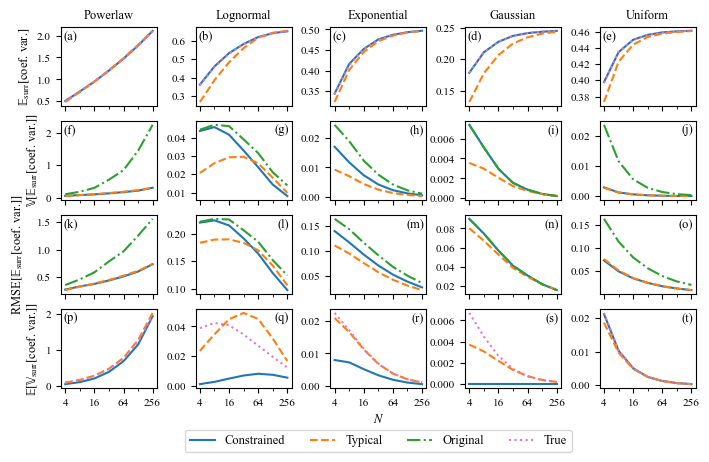

In [3]:
# stat_name_list: ['mean_val', 'second_mom', 'third_mom', 'fourth_mom', 'max_val', 'variance', 'coef_var', 'dispersion', 'skew', 'kurtosis', 'evi_mom', 'evi_smooth']
stat_full_name_list = ['mean', 'second mom.', 'third mom.', 'fourth mom.', 'max.', 'variance', 'coef. var.', 'dispersion', 'skewness', 'kurtosis', 'extr. val. ind. (moment)', 'extr. val. ind. (smooth)']
# stat_full_name_list = ['mean', 'second mom', 'third mom', 'fourth mom', 'maximum', 'variance', 'coeff var', 'dispersion', 'skewness', 'kurtosis', 'extreme val ind (moment)', 'extreme val ind (smooth)']
# i_stat_to_consider_list = [4, 6, 8]#['max_val', 'coef_var', 'skew']
# i_stat_to_consider_list = [0, 4, 6]#['mean_val', 'max_val', 'coef_var']
i_stat_to_consider_list = [4, 6]#['max_val', 'coef_var']
# i_stat_to_consider_list = [6]#['coef_var']
num_stats_to_consider = len(i_stat_to_consider_list)

# process_full_name_list = ['power-law', 'lognormal', 'exponential', 'Gaussian', 'uniform']

num_rows = 4

base_font_size = 9; set_main_fonts(base_font_size=base_font_size)#Set font size and style
label_font_size = 1.0*base_font_size;

for i_stat_to_consider in range(num_stats_to_consider):
    
    i_stat = i_stat_to_consider_list[i_stat_to_consider]
    stat_name = stat_name_list[i_stat]
    full_stat_name = stat_full_name_list[i_stat]
    
    i_row = 0
    meth_to_consider_list = [0, 1, 3]#constrained, typical, true
    #meth_to_consider_list = [0, 1, 2, 3]#constrained, typical, original, true
    
    fig, ax_array = plt.subplots(num_rows, num_processes, sharex=True, figsize=(7.0, 4))
    
    for i_process in range(num_processes):
        process = process_list[i_process]
        #process_full_name = process_full_name_list[i_process]
        ax = ax_array[i_row, i_process]
        ax.set_title(beautify_distribution_name(process))
        for i_method in meth_to_consider_list:#['constrained', 'typical', 'original', 'true', 'bootstrap']
            method = method_list[i_method]
            method_name = beautify_method_name(method)
            mean_list = mean_mean_mat[:, i_method, i_process, i_stat]
            #mean_var_list = mean_var_mat[:, i_method, i_process, i_stat]
            #err_mean_list = np.sqrt(mean_var_list)
            ax.errorbar(N_list, mean_list, label=method_name, linestyle=line_style_list[i_method], color=col_list[i_method])
            if (i_method == 0):
                y1 = min(mean_list)
                y2 = max(mean_list)
                y_delta = y2 - y1
                y_mid = 0.5*(y1 + y2)
                #ax.set_ylim([y_mid - y_delta, y_mid + y_delta])
            if (i_process == 0):
                ax.set_ylabel('$\\rm\\mathbb{E}_{\\text{surr}}[$' + full_stat_name + '$]$')
                if (i_stat == 4):
                    ax.set_yscale('log')
        fix_y_ticks(ax)
        corner = 'upper left'
        if (i_stat == 4):
            if (i_process == 0):
                corner = 'upper right'
        panel_label = get_panel_label(ax, ax_array, order='row-major')
        add_panel_label(ax, panel_label, corner=corner, offset='auto')

    i_row = 1
    #meth_to_consider_list = [0, 2]#constrained, original
    meth_to_consider_list = [0, 1, 2]#constrained, typical, original
    stat_name = stat_name_list[i_stat]
    full_stat_name = stat_full_name_list[i_stat]
    for i_process in range(num_processes):
        process = process_list[i_process]
        #process_full_name = process_full_name_list[i_process]
        ax = ax_array[i_row, i_process]
        for i_method in meth_to_consider_list:#['constrained', 'typical', 'original', 'true', 'bootstrap']
            method = method_list[i_method]
            method_name = beautify_method_name(method)
            var_mean_list = var_mean_mat[:, i_method, i_process, i_stat]
            ax.errorbar(N_list, var_mean_list, label=method_name, linestyle=line_style_list[i_method], color=col_list[i_method])
            if (i_process == 0):
                ax.set_ylabel('$\\rm\\mathbb{V}[\\mathbb{E}_{\\text{surr}}[$' + full_stat_name + '$]]$')
                if (i_stat == 4):
                    ax.set_yscale('log')
        fix_y_ticks(ax)
        corner = 'upper left'
        if (i_stat == 4):
            if (i_process in [0, 3, 4]):
                corner = 'upper right'
            if (i_process in [2]):
                corner = 'lower left'
        if (i_stat == 6):
            if (i_process in [1, 2, 3, 4]):
                corner = 'upper right'
        panel_label = get_panel_label(ax, ax_array, order='row-major')
        add_panel_label(ax, panel_label, corner=corner, offset='auto')
    
    i_row = 2
    #meth_to_consider_list = [0, 2]#constrained, original
    #meth_to_consider_list = [0, 1, 2]#constrained, typical, original
    meth_to_consider_list = [0, 1, 2, 3]#constrained, typical, original, true
    stat_name = stat_name_list[i_stat]
    full_stat_name = stat_full_name_list[i_stat]
    for i_process in range(num_processes):
        process = process_list[i_process]
        #process_full_name = process_full_name_list[i_process]
        ax = ax_array[i_row, i_process]
        for i_method in meth_to_consider_list:#['constrained', 'typical', 'original', 'true', 'bootstrap']
            method = method_list[i_method]
            method_name = beautify_method_name(method)
            rmse_mean_list = rmse_mean_mat[:, i_method, i_process, i_stat]
            if (i_method == 3):
                rmse_mean_list = np.nan*rmse_mean_list#We only include 'true' in this row for the legend
            ax.errorbar(N_list, rmse_mean_list, label=method_name, linestyle=line_style_list[i_method], color=col_list[i_method])
            if (i_process == 0):
                if (i_stat == 6):
                    ax.set_ylabel('RMSE$\\rm[\\mathbb{E}_{\\text{surr}}[$' + full_stat_name + '$]]$', labelpad=9)
                else:
                    ax.set_ylabel('RMSE$\\rm[\\mathbb{E}_{\\text{surr}}[$' + full_stat_name + '$]]$')
                if (i_stat == 4):
                    ax.set_yscale('log')
        fix_y_ticks(ax)
        corner = 'upper left'
        if (i_stat == 4):
            if (i_process in [0, 3, 4]):
                corner = 'upper right'
            if (i_process in [2]):
                corner = 'lower left'
        if (i_stat == 6):
            if (i_process in [1, 2, 3, 4]):
                corner = 'upper right'
        panel_label = get_panel_label(ax, ax_array, order='row-major')
        add_panel_label(ax, panel_label, corner=corner, offset='auto')

    i_row = 3
    #meth_to_consider_list = [0, 2]#constrained, original
    meth_to_consider_list = [0, 1, 3]#constrained, typical, true
    stat_name = stat_name_list[i_stat]
    full_stat_name = stat_full_name_list[i_stat]
    for i_process in range(num_processes):
        process = process_list[i_process]
        #process_full_name = process_full_name_list[i_process]
        ax = ax_array[i_row, i_process]
        for i_method in meth_to_consider_list:#['constrained', 'typical', 'original', 'true', 'bootstrap']
            method = method_list[i_method]
            method_name = beautify_method_name(method)
            mean_var_list = mean_var_mat[:, i_method, i_process, i_stat]
            ax.errorbar(N_list, mean_var_list, label=method_name, linestyle=line_style_list[i_method], color=col_list[i_method])
            if (i_process == 0):
                ax.set_ylabel('$\\rm\\mathbb{E}[\\mathbb{V}_{\\text{surr}}[$' + full_stat_name + '$]]$')
                if (i_stat == 4):
                    ax.set_yscale('log')
        if (i_process == 2):
            ax.set_xlabel('$N$')
        if (i_stat_to_consider == 2) and (i_process == 0):
            ax.set_yticks([10**-1, 1])
        fix_y_ticks(ax)
        corner = 'upper right'
        if (i_stat == 4):
            if (i_process in [2]):
                corner = 'lower right'
        if (i_stat == 6):
            if (i_process in [0]):
                corner = 'upper left'
        panel_label = get_panel_label(ax, ax_array, order='row-major')
        add_panel_label(ax, panel_label, corner=corner, offset='auto')
        
    ax.set_xscale('log')
    ax.xaxis.set_minor_locator(LogLocator(base=2, numticks=num_N + 1))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xticks(N_tick_list)
    ax.set_xticklabels(N_tick_list)
    
    # For legend (possibly sub-omptimal because it reuses previous labels of lines):
    ax = ax_array[i_row, 2]
    meth_to_consider_list = [0, 1, 2, 3]#constrained, typical, original, true
    handle_list = []
    label_list = []
    for i_method in meth_to_consider_list:
        method = method_list[i_method]
        line = ax.errorbar(np.nan, np.nan, linestyle=line_style_list[i_method], color=col_list[i_method])
        handle_list = handle_list + [line[0]]
        method_name = beautify_method_name(method)
        label_list = label_list + [method_name]
    ax.legend(handle_list, label_list, ncol=4, loc = 'lower center', bbox_to_anchor=(0.5, -0.9))
    
    plt.subplots_adjust(wspace=0.4, hspace=0.2)
    
    bbox = fig.get_tightbbox(fig.canvas.get_renderer())
    scale = fig.get_figwidth()/bbox.width
    fig.set_size_inches(fig.get_size_inches()*scale, forward=True)
    
    plt.savefig('figures\\' + 'estimation-vs-N-' + str(stat_name) + '-2' + '.png', bbox_inches='tight')
    plt.savefig('figures\\' + 'estimation-vs-N-' + str(stat_name) + '-2' + '.pdf', bbox_inches='tight')
    plt.show()

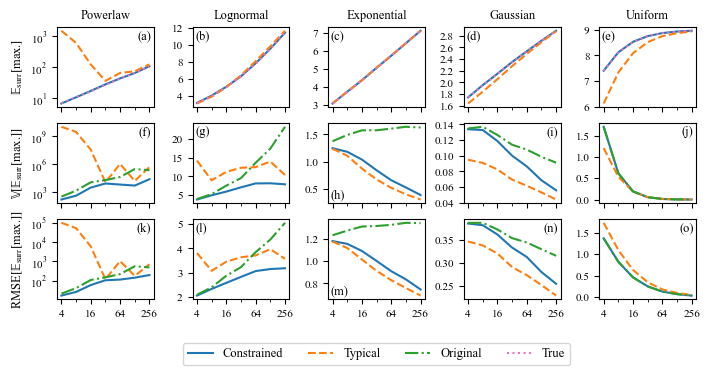

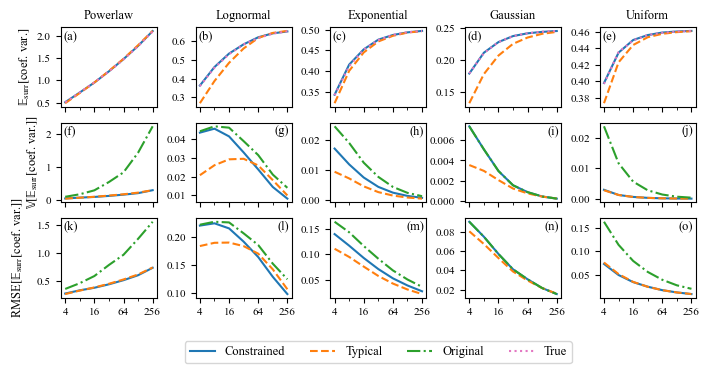

In [4]:
# stat_name_list: ['mean_val', 'second_mom', 'third_mom', 'fourth_mom', 'max_val', 'variance', 'coef_var', 'dispersion', 'skew', 'kurtosis', 'evi_mom', 'evi_smooth']
stat_full_name_list = ['mean', 'second mom.', 'third mom.', 'fourth mom.', 'max.', 'variance', 'coef. var.', 'dispersion', 'skewness', 'kurtosis', 'extr. val. ind. (moment)', 'extr. val. ind. (smooth)']
# stat_full_name_list = ['mean', 'second mom', 'third mom', 'fourth mom', 'maximum', 'variance', 'coeff var', 'dispersion', 'skewness', 'kurtosis', 'extreme val ind (moment)', 'extreme val ind (smooth)']
# i_stat_to_consider_list = [4, 6, 8]#['max_val', 'coef_var', 'skew']
# i_stat_to_consider_list = [0, 4, 6]#['mean_val', 'max_val', 'coef_var']
i_stat_to_consider_list = [4, 6]#['max_val', 'coef_var']
# i_stat_to_consider_list = [6]#['coef_var']
num_stats_to_consider = len(i_stat_to_consider_list)

# process_full_name_list = ['power-law', 'lognormal', 'exponential', 'Gaussian', 'uniform']

num_rows = 3

base_font_size = 9; set_main_fonts(base_font_size=base_font_size)#Set font size and style
label_font_size = 1.0*base_font_size;

for i_stat_to_consider in range(num_stats_to_consider):
    
    i_stat = i_stat_to_consider_list[i_stat_to_consider]
    stat_name = stat_name_list[i_stat]
    full_stat_name = stat_full_name_list[i_stat]
    
    i_row = 0
    meth_to_consider_list = [0, 1, 3]#constrained, typical, true
    #meth_to_consider_list = [0, 1, 2, 3]#constrained, typical, original, true
    
    fig, ax_array = plt.subplots(num_rows, num_processes, sharex=True, figsize=(7.0, 3))
    
    for i_process in range(num_processes):
        process = process_list[i_process]
        #process_full_name = process_full_name_list[i_process]
        ax = ax_array[i_row, i_process]
        ax.set_title(beautify_distribution_name(process))
        for i_method in meth_to_consider_list:#['constrained', 'typical', 'original', 'true', 'bootstrap']
            method = method_list[i_method]
            method_name = beautify_method_name(method)
            mean_list = mean_mean_mat[:, i_method, i_process, i_stat]
            #mean_var_list = mean_var_mat[:, i_method, i_process, i_stat]
            #err_mean_list = np.sqrt(mean_var_list)
            ax.errorbar(N_list, mean_list, label=method_name, linestyle=line_style_list[i_method], color=col_list[i_method])
            if (i_method == 0):
                y1 = min(mean_list)
                y2 = max(mean_list)
                y_delta = y2 - y1
                y_mid = 0.5*(y1 + y2)
                #ax.set_ylim([y_mid - y_delta, y_mid + y_delta])
            if (i_process == 0):
                ax.set_ylabel('$\\rm\\mathbb{E}_{\\text{surr}}[$' + full_stat_name + '$]$')
                if (i_stat == 4):
                    ax.set_yscale('log')
        fix_y_ticks(ax)
        corner = 'upper left'
        if (i_stat == 4):
            if (i_process == 0):
                corner = 'upper right'
        panel_label = get_panel_label(ax, ax_array, order='row-major')
        add_panel_label(ax, panel_label, corner=corner, offset='auto')

    i_row = 1
    #meth_to_consider_list = [0, 2]#constrained, original
    meth_to_consider_list = [0, 1, 2]#constrained, typical, original
    stat_name = stat_name_list[i_stat]
    full_stat_name = stat_full_name_list[i_stat]
    for i_process in range(num_processes):
        process = process_list[i_process]
        #process_full_name = process_full_name_list[i_process]
        ax = ax_array[i_row, i_process]
        for i_method in meth_to_consider_list:#['constrained', 'typical', 'original', 'true', 'bootstrap']
            method = method_list[i_method]
            method_name = beautify_method_name(method)
            var_mean_list = var_mean_mat[:, i_method, i_process, i_stat]
            ax.errorbar(N_list, var_mean_list, label=method_name, linestyle=line_style_list[i_method], color=col_list[i_method])
            if (i_process == 0):
                ax.set_ylabel('$\\rm\\mathbb{V}[\\mathbb{E}_{\\text{surr}}[$' + full_stat_name + '$]]$')
                if (i_stat == 4):
                    ax.set_yscale('log')
        fix_y_ticks(ax)
        corner = 'upper left'
        if (i_stat == 4):
            if (i_process in [0, 3, 4]):
                corner = 'upper right'
            if (i_process in [2]):
                corner = 'lower left'
        if (i_stat == 6):
            if (i_process in [1, 2, 3, 4]):
                corner = 'upper right'
        panel_label = get_panel_label(ax, ax_array, order='row-major')
        add_panel_label(ax, panel_label, corner=corner, offset='auto')
    
    i_row = 2
    #meth_to_consider_list = [0, 2]#constrained, original
    #meth_to_consider_list = [0, 1, 2]#constrained, typical, original
    meth_to_consider_list = [0, 1, 2, 3]#constrained, typical, original, true
    stat_name = stat_name_list[i_stat]
    full_stat_name = stat_full_name_list[i_stat]
    for i_process in range(num_processes):
        process = process_list[i_process]
        #process_full_name = process_full_name_list[i_process]
        ax = ax_array[i_row, i_process]
        for i_method in meth_to_consider_list:#['constrained', 'typical', 'original', 'true', 'bootstrap']
            method = method_list[i_method]
            method_name = beautify_method_name(method)
            rmse_mean_list = rmse_mean_mat[:, i_method, i_process, i_stat]
            if (i_method == 3):
                rmse_mean_list = np.nan*rmse_mean_list#We only include 'true' in this row for the legend
            ax.errorbar(N_list, rmse_mean_list, label=method_name, linestyle=line_style_list[i_method], color=col_list[i_method])
            if (i_process == 0):
                if (i_stat == 6):
                    ax.set_ylabel('RMSE$\\rm[\\mathbb{E}_{\\text{surr}}[$' + full_stat_name + '$]]$', labelpad=9)
                else:
                    ax.set_ylabel('RMSE$\\rm[\\mathbb{E}_{\\text{surr}}[$' + full_stat_name + '$]]$')
                if (i_stat == 4):
                    ax.set_yscale('log')
        fix_y_ticks(ax)
        corner = 'upper left'
        if (i_stat == 4):
            if (i_process in [0, 3, 4]):
                corner = 'upper right'
            if (i_process in [2]):
                corner = 'lower left'
        if (i_stat == 6):
            if (i_process in [1, 2, 3, 4]):
                corner = 'upper right'
        panel_label = get_panel_label(ax, ax_array, order='row-major')
        add_panel_label(ax, panel_label, corner=corner, offset='auto')
        
    ax.set_xscale('log')
    ax.xaxis.set_minor_locator(LogLocator(base=2, numticks=num_N + 1))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xticks(N_tick_list)
    ax.set_xticklabels(N_tick_list)
    
    # For legend (possibly sub-omptimal because it reuses previous labels of lines):
    ax = ax_array[i_row, 2]
    meth_to_consider_list = [0, 1, 2, 3]#constrained, typical, original, true
    handle_list = []
    label_list = []
    for i_method in meth_to_consider_list:
        method = method_list[i_method]
        line = ax.errorbar(np.nan, np.nan, linestyle=line_style_list[i_method], color=col_list[i_method])
        handle_list = handle_list + [line[0]]
        method_name = beautify_method_name(method)
        label_list = label_list + [method_name]
    ax.legend(handle_list, label_list, ncol=4, loc = 'lower center', bbox_to_anchor=(0.5, -0.9))
    
    plt.subplots_adjust(wspace=0.4, hspace=0.2)
    
    bbox = fig.get_tightbbox(fig.canvas.get_renderer())
    scale = fig.get_figwidth()/bbox.width
    fig.set_size_inches(fig.get_size_inches()*scale, forward=True)
    
    plt.savefig('figures\\' + 'estimation-vs-N-' + str(stat_name) + '-3' + '.png', bbox_inches='tight')
    plt.savefig('figures\\' + 'estimation-vs-N-' + str(stat_name) + '-3' + '.pdf', bbox_inches='tight')
    plt.show()